# 04 — Demand Forecasting Model

**Layer:** Machine learning  
**Objective:** Predict next month's waiting list size (`target_total_next`) per provider × specialty, and demonstrate that a gradient-boosted model improves on naive baselines.  
**Input:** `data/processed/rtt_features.parquet`.  
**Model:** XGBoost regressor.  
**Baselines:** persistence (next = current) and drift (next = current + last month's change).

**Evaluation protocol:** strictly time-based split — train on earlier months, test on the most recent months. A random split would leak future information into training and overstate performance.

**Metrics:** MAE and RMSE (absolute error, in patients); MAPE on series with >= 100 waiting (percentage error is unstable for very small lists).

**Execution:** select the `Python (HCIP)` kernel, then run all cells in order.

## 1. Load and define features / target

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


def resolve_dir(*parts: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base.joinpath(*parts)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not locate '{Path(*parts)}'.")


FEATURES_PATH = resolve_dir("data", "processed") / "rtt_features.parquet"
TARGET = "target_total_next"
TEST_FROM = pd.Timestamp("2025-12-01")  # final 3 months held out for testing

# Current-month values are known at prediction time and are legitimate predictors of next month.
FEATURE_COLS = [
    "total_waiting", "pct_within_18wk", "breach_rate", "over_52_share", "over_104_share",
    "month", "quarter", "month_sin", "month_cos",
    "lag1_total", "lag2_total", "lag3_total", "lag12_total", "lag1_breach", "lag12_breach",
    "roll3_total", "roll6_total", "roll12_total", "roll3_std_total",
    "mom_change_total", "mom_pct_total", "yoy_pct_total",
]

df = pd.read_parquet(FEATURES_PATH)
# Require a target and the columns the baselines depend on.
df = df.dropna(subset=[TARGET, "total_waiting", "lag1_total"]).reset_index(drop=True)
print(f"Modelling rows: {len(df):,}")
print(f"Feature count:  {len(FEATURE_COLS)}")

Modelling rows: 77,379
Feature count:  22


## 2. Time-based train / test split

Train on every month before December 2025; test on December 2025 onward (predicting January–March 2026). The split is on the feature month, so no test-period information is seen during training.

In [2]:
train = df[df["period_date"] < TEST_FROM]
test = df[df["period_date"] >= TEST_FROM]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f"Train: {len(train):,} rows  ({train['period_date'].min():%Y-%m} to {train['period_date'].max():%Y-%m})")
print(f"Test:  {len(test):,} rows  ({test['period_date'].min():%Y-%m} to {test['period_date'].max():%Y-%m})")

Train: 66,859 rows  (2024-05 to 2025-11)
Test:  10,520 rows  (2025-12 to 2026-02)


## 3. Baselines and the metric helper

Persistence predicts next month equals this month. Drift adds last month's change. These are the bars the model must clear.

In [3]:
def evaluate(name: str, y_true: pd.Series, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true >= 100  # MAPE only where the list is non-trivial
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_%": mape,
    }


pred_persistence = test["total_waiting"].to_numpy()
pred_drift = (test["total_waiting"] + (test["total_waiting"] - test["lag1_total"])).to_numpy()

results = [
    evaluate("Persistence", y_test, pred_persistence),
    evaluate("Drift", y_test, pred_drift),
]
pd.DataFrame(results)

,model,MAE,RMSE,MAPE_%
0,Persistence,89.553992,197.270290,7.029045
1,Drift,110.012357,251.817115,9.028919


## 4. Train the XGBoost regressor

Gradient boosting handles missing feature values natively (early-history lags), so no imputation is required.

In [4]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
pred_xgb = model.predict(X_test)
results.append(evaluate("XGBoost", y_test, pred_xgb))
print("Trained.")

Trained.


## 5. Results

Lower is better on all three metrics. XGBoost should improve on both baselines.

In [5]:
scoreboard = pd.DataFrame(results).set_index("model").round(1)
best_mae = scoreboard["MAE"].idxmin()
improvement = 1 - scoreboard.loc["XGBoost", "MAE"] / scoreboard.loc["Persistence", "MAE"]
print(f"Best MAE: {best_mae}")
print(f"XGBoost MAE improvement over persistence: {improvement:.1%}")
scoreboard

Best MAE: Persistence
XGBoost MAE improvement over persistence: -6.4%


,MAE,RMSE,MAPE_%
model,,,
Persistence,89.6,197.3,7.0
Drift,110.0,251.8,9.0
XGBoost,95.3,245.4,7.2


## 6. Feature importance

Which signals the model relied on most.

In [6]:
importance = (
    pd.Series(model.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
)
importance.head(12)

total_waiting      0.530966
roll3_total        0.428990
roll6_total        0.009120
lag1_total         0.008987
roll12_total       0.006632
pct_within_18wk    0.003416
breach_rate        0.002126
lag12_total        0.001291
over_52_share      0.001162
yoy_pct_total      0.000988
lag3_total         0.000845
lag1_breach        0.000818
dtype: float32

## 7. Diagnostics

Left: national waiting list, actual vs predicted, summed across all providers/specialties per test month. Right: predicted vs actual per series (the diagonal is a perfect prediction).

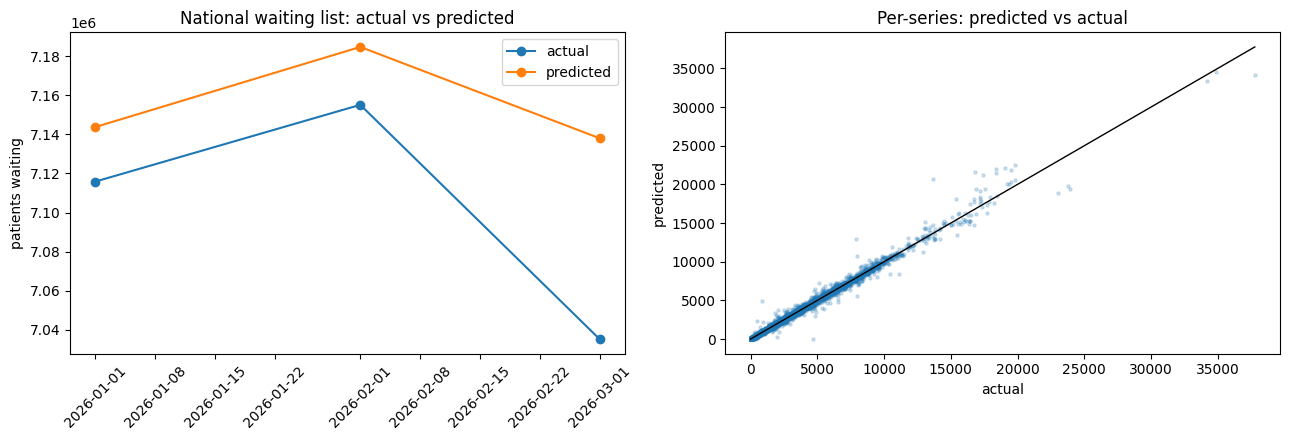

In [7]:
test_eval = test.copy()
test_eval["xgb_pred"] = pred_xgb
national = test_eval.groupby(test_eval["period_date"] + pd.offsets.MonthBegin(1)).agg(
    actual=("target_total_next", "sum"), predicted=("xgb_pred", "sum")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(national.index, national["actual"], marker="o", label="actual")
axes[0].plot(national.index, national["predicted"], marker="o", label="predicted")
axes[0].set_title("National waiting list: actual vs predicted")
axes[0].set_ylabel("patients waiting")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

axes[1].scatter(y_test, pred_xgb, s=5, alpha=0.2)
lim = [0, max(y_test.max(), pred_xgb.max())]
axes[1].plot(lim, lim, color="black", linewidth=1)
axes[1].set_title("Per-series: predicted vs actual")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("predicted")
plt.tight_layout()
plt.show()

## 8. Findings

_To be completed after execution: record MAE/RMSE/MAPE for each model, the % improvement over persistence, the dominant features, and any provider/specialty segments where the model underperforms._